# Python Basics, Data Types, Functions, Classes, NumPy, and Full PDF Exercise Solution

This notebook is a detailed learning notebook. It expands the uploaded notebooks on Python basics, NumPy, functions, and classes, and then solves the uploaded PDF exercise `Sheet01.pdf` about **functions as objects** and **optimization with SciPy**.

The notebook is written for a beginner, but it also connects the ideas to scientific computing, numerical methods, FEM-style workflows, and optimization.

## Contents

1. Setup
2. Python basics and variables
3. Data types
4. Containers: lists, tuples, dictionaries, sets
5. Control flow: `if`, `for`, `while`
6. Functions in detail
7. Classes and inheritance
8. NumPy in detail
9. Full solution of the PDF exercise
10. Extra practice problems with solutions

# 1. Setup

We import all libraries at the beginning.

- `math`: elementary mathematical functions.
- `numpy`: vectors, matrices, numerical computing.
- `pandas`: clean result tables.
- `matplotlib`: plots.
- `scipy.optimize.minimize`: optimization solver used for the PDF exercise.

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 2. Python Basics

## 2.1 Variables

A Python variable is like a label attached to an object.

Example:

```python
x = 5
```

means: create the object `5`, then attach the name `x` to it.

Python is dynamically typed. You do not write the type explicitly. Python understands the type from the value.

In [3]:
x = 5
print("x =", x)
print("type of x:", type(x))

x = 5.0
print("\nAfter changing x:")
print("x =", x)
print("type of x:", type(x))

x = "Python"
print("\nAfter changing x again:")
print("x =", x)
print("type of x:", type(x))

x = 5
type of x: <class 'int'>

After changing x:
x = 5.0
type of x: <class 'float'>

After changing x again:
x = Python
type of x: <class 'str'>


## 2.2 Arithmetic operators

Python can be used like a calculator.

| Operator | Meaning | Example |
|---|---|---|
| `+` | addition | `2 + 3` |
| `-` | subtraction | `5 - 2` |
| `*` | multiplication | `4 * 3` |
| `/` | division | `5 / 2 = 2.5` |
| `//` | floor division | `5 // 2 = 2` |
| `%` | remainder | `5 % 2 = 1` |
| `**` | power | `2 ** 3 = 8` |

The power operator `**` is important in mathematics, optimization, and mechanics because formulas often contain terms like \(x^2\), \(v^2\), or \(r^3\).

In [4]:
a = 7
b = 2

print("a + b  =", a + b)
print("a - b  =", a - b)
print("a * b  =", a * b)
print("a / b  =", a / b)
print("a // b =", a // b)
print("a % b  =", a % b)
print("a ** b =", a ** b)

a + b  = 9
a - b  = 5
a * b  = 14
a / b  = 3.5
a // b = 3
a % b  = 1
a ** b = 49


## 2.3 Mathematical mini-example: kinetic energy

In mechanics, kinetic energy is

\[
E_k = \frac{1}{2}mv^2.
\]

Here:

- \(m\): mass,
- \(v\): velocity.

This simple example already shows how Python formulas can look almost like mathematical formulas.

In [5]:
m = 2.5     # kg
v = 4.0     # m/s
E_k = 0.5 * m * v**2
print("Kinetic energy =", E_k, "J")

Kinetic energy = 20.0 J


# 3. Data Types

Python objects have data types. The type controls what operations are possible.

| Type | Example | Meaning |
|---|---|---|
| `int` | `5` | integer |
| `float` | `5.2` | decimal number |
| `bool` | `True` | logical value |
| `str` | `'hello'` | text |
| `complex` | `2 + 3j` | complex number |

In scientific computing, the most common scalar types are `int` and `float`. For real numerical work, we usually move to NumPy arrays of floats.

In [6]:
values = [10, 10.5, True, "FEM", 2 + 3j]

for value in values:
    print(value, "-->", type(value))

10 --> <class 'int'>
10.5 --> <class 'float'>
True --> <class 'bool'>
FEM --> <class 'str'>
(2+3j) --> <class 'complex'>


## 3.1 Type conversion

Sometimes we need to convert one type into another.

Examples:

```python
float(3)
int(3.9)
str(10)
```

Be careful: converting a float to an integer cuts off the decimal part.

In [7]:
a = 3
b = float(a)
print(a, type(a))
print(b, type(b))

c = 3.9
d = int(c)
print("\nint(3.9) =", d)

number_as_text = str(100)
print("\nnumber_as_text =", number_as_text, type(number_as_text))

3 <class 'int'>
3.0 <class 'float'>

int(3.9) = 3

number_as_text = 100 <class 'str'>


## 3.2 Booleans and comparisons

A Boolean is either `True` or `False`.

Comparison operators are used in conditions and stopping criteria.

For example, in optimization we may stop when

\[
\|\nabla f(x)\| < 10^{-6}.
\]

In [8]:
error = 1e-7
tolerance = 1e-6

print("error < tolerance:", error < tolerance)
print("error == tolerance:", error == tolerance)
print("error != tolerance:", error != tolerance)

error < tolerance: True
error == tolerance: False
error != tolerance: True


## 3.3 Strings

A string is text. Strings are useful for labels, filenames, printed messages, and reports.

Python uses zero-based indexing:

```python
text[0]
```

means the first character.

In [9]:
text = "Optimization"
print("Full text:", text)
print("First character:", text[0])
print("Last character:", text[-1])
print("First 5 characters:", text[:5])
print("Characters from index 3 to 7:", text[3:8])

Full text: Optimization
First character: O
Last character: n
First 5 characters: Optim
Characters from index 3 to 7: imiza


## 3.4 F-strings

F-strings are used to insert variables into strings.

They are very useful when printing numerical results.

In [10]:
x = math.pi
print(f"pi without formatting: {x}")
print(f"pi with 3 decimals: {x:.3f}")
print(f"pi in scientific notation: {x:.3e}")

pi without formatting: 3.141592653589793
pi with 3 decimals: 3.142
pi in scientific notation: 3.142e+00


# 4. Container Data Types

Containers store many values.

| Type | Example | Mutable? | Use |
|---|---|---:|---|
| list | `[1, 2, 3]` | yes | flexible ordered collection |
| tuple | `(1, 2, 3)` | no | fixed ordered collection |
| dictionary | `{"E": 210e9}` | yes | key-value pairs |
| set | `{1, 2, 3}` | yes | unique entries |

## 4.1 Lists

A list is like a row of boxes. You can change entries, append new entries, and loop over it.

In [11]:
loads = [10, 20, 30]
print("Original loads:", loads)

loads.append(40)
print("After append:", loads)

loads[0] = 15
print("After changing first entry:", loads)

for load in loads:
    print("load =", load)

Original loads: [10, 20, 30]
After append: [10, 20, 30, 40]
After changing first entry: [15, 20, 30, 40]
load = 15
load = 20
load = 30
load = 40


## 4.2 Tuples

A tuple is fixed after creation. It is useful for data that should not be modified accidentally, such as a coordinate pair.

In [12]:
point = (3.0, 2.0)
print("point =", point)
print("x-coordinate =", point[0])
print("y-coordinate =", point[1])

point = (3.0, 2.0)
x-coordinate = 3.0
y-coordinate = 2.0


## 4.3 Dictionaries

A dictionary stores values using keys. This is very useful for material parameters.

In [13]:
steel = {
    "name": "steel",
    "Young_modulus": 210e9,
    "Poisson_ratio": 0.3,
    "density": 7850,
}

print("Material:", steel["name"])
print("Young's modulus:", steel["Young_modulus"], "Pa")
print("Poisson ratio:", steel["Poisson_ratio"])
print("Density:", steel["density"], "kg/m^3")

Material: steel
Young's modulus: 210000000000.0 Pa
Poisson ratio: 0.3
Density: 7850 kg/m^3


## 4.4 Sets

A set stores unique values. Duplicate values are removed.

In [14]:
methods = {"CG", "BFGS", "CG", "Newton-CG"}
print(methods)

{'BFGS', 'Newton-CG', 'CG'}


# 5. Control Flow

Control flow decides what code runs and how often.

The most important tools are:

- `if`, `elif`, `else`,
- `for` loops,
- `while` loops.

## 5.1 If statements

An `if` statement is used for decisions.

In [15]:
stress = 250.0       # MPa
yield_stress = 235.0 # MPa

if stress > yield_stress:
    print("Plastic deformation may occur.")
else:
    print("Material remains elastic.")

Plastic deformation may occur.


## 5.2 For loops

A `for` loop repeats code for each element in a sequence.

In [16]:
numbers = [1, 2, 3, 4, 5]

for number in numbers:
    print(f"{number} squared is {number**2}")

1 squared is 1
2 squared is 4
3 squared is 9
4 squared is 16
5 squared is 25


## 5.3 While loops

A `while` loop repeats while a condition is true.

This is similar to an iterative solver:

1. Start with an error.
2. Improve the solution.
3. Reduce the error.
4. Stop when the error is small enough.

In [17]:
error = 1.0
tolerance = 1e-3
iteration = 0

while error > tolerance:
    iteration += 1
    error = error / 2
    print(f"iteration = {iteration:2d}, error = {error:.6f}")

iteration =  1, error = 0.500000
iteration =  2, error = 0.250000
iteration =  3, error = 0.125000
iteration =  4, error = 0.062500
iteration =  5, error = 0.031250
iteration =  6, error = 0.015625
iteration =  7, error = 0.007812
iteration =  8, error = 0.003906
iteration =  9, error = 0.001953
iteration = 10, error = 0.000977


# 6. Functions in Detail

A function is a reusable block of code.

Mathematically:

\[
f:x\mapsto y.
\]

In Python:

```python
def f(x):
    return x**2
```

Functions make scientific code clean, reusable, and testable.

## 6.1 Simple function

Let us write a function for kinetic energy:

\[
E_k(m,v)=\frac{1}{2}mv^2.
\]

In [18]:
def kinetic_energy(m, v):
    return 0.5 * m * v**2

print(kinetic_energy(2.5, 4.0))

20.0


## 6.2 Function with multiple return values

A function can return several values. Python returns them as a tuple.

In [19]:
def rectangle_properties(width, height):
    area = width * height
    perimeter = 2 * (width + height)
    return area, perimeter

A, P = rectangle_properties(3, 4)
print("Area =", A)
print("Perimeter =", P)

Area = 12
Perimeter = 14


## 6.3 Default arguments

Default arguments are used when a parameter should have a standard value.

In [20]:
def linear_function(x, slope=1.0, intercept=0.0):
    return slope * x + intercept

print(linear_function(5))
print(linear_function(5, slope=2))
print(linear_function(5, slope=2, intercept=3))

5.0
10.0
13


## 6.4 Scope

A variable created inside a function is usually local. It exists only inside that function.

In [21]:
def compute_area(radius):
    local_area = math.pi * radius**2
    return local_area

area = compute_area(2)
print("area =", area)


area = 12.566370614359172


## 6.5 Functions as objects

In Python, functions are objects. A function can be stored in a variable or passed into another function.

This is the basic idea behind `scipy.optimize.minimize`: we give SciPy a function object, and SciPy calls it many times.

In [22]:
def square(x):
    return x**2

my_function = square
print("my_function(5) =", my_function(5))

functions = [math.sin, math.cos, square]
for f in functions:
    print(f.__name__, "at x=0.5 gives", f(0.5))

my_function(5) = 25
sin at x=0.5 gives 0.479425538604203
cos at x=0.5 gives 0.8775825618903728
square at x=0.5 gives 0.25


## 6.6 Exercise: vector norm

Write a function for the Euclidean norm of a 2D vector:

\[
\|x\|=\sqrt{x_1^2+x_2^2}.
\]

For \((3,4)\), the norm is \(5\).

In [23]:
def vector_norm_2d(x1, x2):
    return math.sqrt(x1**2 + x2**2)

print(vector_norm_2d(3, 4))

5.0


# 7. Classes and Object-Oriented Programming

A class is a blueprint for creating objects.

Daily-life analogy:

- Class: blueprint of a car.
- Object: one real car.
- Attributes: mass, color, velocity.
- Methods: accelerate, brake, compute energy.

Scientific-computing analogy:

- Class: mathematical function definition.
- Object: one concrete function with chosen parameters.
- Attributes: matrix \(Q\), vector \(p\), dimension \(n\).
- Methods: value, gradient, Hessian.

This is exactly the idea used in the PDF exercise.

## 7.1 A first class

In [24]:
class Particle:
    def __init__(self, mass, velocity):
        self.mass = mass
        self.velocity = velocity

    def kinetic_energy(self):
        return 0.5 * self.mass * self.velocity**2

particle = Particle(mass=2.5, velocity=4.0)
print("mass =", particle.mass)
print("velocity =", particle.velocity)
print("kinetic energy =", particle.kinetic_energy())

mass = 2.5
velocity = 4.0
kinetic energy = 20.0


## 7.2 Why classes are useful for optimization

For an optimization problem, we often need:

\[
f(x),\qquad \nabla f(x),\qquad \nabla^2 f(x).
\]

Instead of keeping these in separate functions, we can group them inside one class:

```python
problem.value(x)
problem.gradient(x)
problem.hessian(x)
```

This makes the code cleaner and closer to mathematical notation.

## 7.3 Inheritance

Inheritance means that one class receives methods from another class.

The PDF uses this idea: a general `Problem` class defines the required methods, and special problems such as `Himmelblau` or `QuadraticFunction` inherit from it.

In [24]:
class DemoProblem:
    def value(self, x):
        raise NotImplementedError("value is not implemented")

class DemoSquare(DemoProblem):
    def value(self, x):
        return x**2

problem = DemoSquare()
print(problem.value(4))

16


# 8. NumPy in Detail

NumPy is the standard package for numerical computing in Python.

It is useful for:

- vectors,
- matrices,
- linear algebra,
- finite differences,
- optimization,
- FEM/CFD postprocessing,
- machine learning preprocessing.

Python lists are flexible, but NumPy arrays are much better for numerical computation.

## 8.1 Creating arrays

In [25]:
a = np.array([1, 2, 3, 4])
print(a)
print(type(a))
print("shape:", a.shape)
print("dtype:", a.dtype)

[1 2 3 4]
<class 'numpy.ndarray'>
shape: (4,)
dtype: int64


## 8.2 Special arrays

In [26]:
print("zeros:")
print(np.zeros(5))

print("\nones:")
print(np.ones(5))

print("\narange:")
print(np.arange(0, 10, 2))

print("\nlinspace:")
print(np.linspace(0, 1, 5))

print("\nidentity matrix:")
print(np.eye(4))

zeros:
[0. 0. 0. 0. 0.]

ones:
[1. 1. 1. 1. 1.]

arange:
[0 2 4 6 8]

linspace:
[0.   0.25 0.5  0.75 1.  ]

identity matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


## 8.3 Vector operations

For vectors \(a\) and \(b\), NumPy performs many operations component-wise.

The dot product is

\[
a\cdot b=\sum_i a_i b_i.
\]

In NumPy, dot product can be written as `a @ b`.

In [27]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("a + b =", a + b)
print("a - b =", a - b)
print("2*a =", 2*a)
print("a*b component-wise =", a*b)
print("a @ b =", a @ b)
print("norm of a =", np.linalg.norm(a))

a + b = [5 7 9]
a - b = [-3 -3 -3]
2*a = [2 4 6]
a*b component-wise = [ 4 10 18]
a @ b = 32
norm of a = 3.7416573867739413


## 8.4 Matrices

Matrix-vector multiplication is written as

\[
y=Ax.
\]

In NumPy:

```python
y = A @ x
```

In [28]:
A = np.array([
    [2, -1],
    [-1, 2]
], dtype=float)

x = np.array([1, 3], dtype=float)
y = A @ x

print("A =")
print(A)
print("x =", x)
print("A @ x =", y)

A =
[[ 2. -1.]
 [-1.  2.]]
x = [1. 3.]
A @ x = [-1.  5.]


## 8.5 Shape and axis

For a matrix:

- `axis=0` means column direction,
- `axis=1` means row direction.

In [29]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

print("A shape:", A.shape)
print("sum of all entries:", A.sum())
print("column sums axis=0:", A.sum(axis=0))
print("row sums axis=1:", A.sum(axis=1))

A shape: (2, 3)
sum of all entries: 21
column sums axis=0: [5 7 9]
row sums axis=1: [ 6 15]


## 8.6 Broadcasting

Broadcasting means NumPy automatically expands a smaller object when the shapes are compatible.

In [30]:
x = np.array([1, 2, 3])
print("x + 10 =", x + 10)
print("x * 2 =", x * 2)

A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])
row_shift = np.array([10, 20, 30])
print("\nA + row_shift =")
print(A + row_shift)

x + 10 = [11 12 13]
x * 2 = [2 4 6]

A + row_shift =
[[11 22 33]
 [14 25 36]]


## 8.7 Vectorization

Vectorization means replacing Python loops with NumPy array operations.

This is usually faster and cleaner.

In [31]:
x = np.linspace(0, 1, 6)

# Loop version
squares_loop = []
for xi in x:
    squares_loop.append(xi**2)

# NumPy version
squares_numpy = x**2

print("x =", x)
print("loop result =", squares_loop)
print("NumPy result =", squares_numpy)

x = [0.  0.2 0.4 0.6 0.8 1. ]
loop result = [np.float64(0.0), np.float64(0.04000000000000001), np.float64(0.16000000000000003), np.float64(0.3600000000000001), np.float64(0.6400000000000001), np.float64(1.0)]
NumPy result = [0.   0.04 0.16 0.36 0.64 1.  ]


## 8.8 Solving a linear system

Solve

\[
Ax=b.
\]

In [32]:
A = np.array([
    [3, 1],
    [1, 2]
], dtype=float)
b = np.array([9, 8], dtype=float)

x = np.linalg.solve(A, b)
print("solution x =", x)
print("check A @ x =", A @ x)

solution x = [2. 3.]
check A @ x = [9. 8.]


# 9. Full Solution of the PDF Exercise

The uploaded PDF asks for two tasks.

## Task 1: Functions as objects

Implement the following functions as derived classes of an abstract `Problem` class.

### Function 1: Himmelblau

\[
f_1(x_1,x_2)=\left(x_1^2+x_2-11\right)^2+\left(x_1+x_2^2-7\right)^2.
\]

### Function 2: Quadratic

\[
f_2(x)=\frac{1}{2}x^TQx+p^Tx+c,
\]

where

\[
Q=T_n,\qquad p=\mathbf{1},\qquad c=0.
\]

### Function 3

\[
f_3(x)=\sqrt{1+x^TQx}.
\]

### Function 4

\[
f_4(x)=\sqrt{1+x^TQx}+\frac{1}{2}x^TQx.
\]

## Task 2: Optimization with SciPy

Use `scipy.optimize.minimize` to minimize the functions.

Questions:

1. Vary the starting value for the Himmelblau function. What do you observe?
2. For \(f_3\) and \(f_4\), use `CG`, `Newton-CG`, and `BFGS`, and vary the tolerance.

## 9.1 Abstract base class `Problem`

The base class defines the interface. A concrete function class should implement:

- `value(x)`,
- `gradient(x)`,
- `hessian(x)`.

If one method is not implemented, it raises a clear error.

In [33]:
class Problem:
    """
    Abstract base class for optimization problems.

    A derived class should implement:
    - value(x)
    - gradient(x)
    - hessian(x)
    """

    def value(self, x):
        raise NotImplementedError("value(x) is not implemented for this problem.")

    def gradient(self, x):
        raise NotImplementedError("gradient(x) is not implemented for this problem.")

    def hessian(self, x):
        raise NotImplementedError("hessian(x) is not implemented for this problem.")


def method_is_implemented(problem, method_name):
    """
    Return True if the concrete problem class overrides the base-class method.
    """
    concrete_method = getattr(type(problem), method_name)
    base_method = getattr(Problem, method_name)
    return concrete_method is not base_method

## 9.2 Check missing methods

This proves that the abstract base class behaves as intended.

In [34]:
class OnlyValueProblem(Problem):
    def value(self, x):
        return x**2

p = OnlyValueProblem()
print("value implemented?", method_is_implemented(p, "value"))
print("gradient implemented?", method_is_implemented(p, "gradient"))
print("hessian implemented?", method_is_implemented(p, "hessian"))

try:
    p.gradient(2.0)
except NotImplementedError as error:
    print("\nExpected error:", error)

value implemented? True
gradient implemented? False
hessian implemented? False

Expected error: gradient(x) is not implemented for this problem.


## 9.3 Matrix \(T_n\)

The matrix in the PDF is

\[
T_n=
\begin{bmatrix}
2 & -1 & 0 & \cdots & 0\\
-1 & 2 & -1 & \cdots & 0\\
0 & -1 & 2 & \cdots & 0\\
\vdots & \vdots & \vdots & \ddots & -1\\
0 & 0 & 0 & -1 & 2
\end{bmatrix}.
\]

This matrix appears in finite differences and simple 1D FEM-like discretizations. It is symmetric positive definite.

In [35]:
def tridiagonal_T(n):
    """
    Build the n x n tridiagonal matrix T_n.
    Diagonal entries: 2
    First off-diagonal entries: -1
    """
    Q = 2 * np.eye(n)
    Q += -1 * np.eye(n, k=1)
    Q += -1 * np.eye(n, k=-1)
    return Q

print(tridiagonal_T(5))

[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]


## 9.4 Himmelblau function: derivation

Let

\[
a=x_1^2+x_2-11,
\qquad
b=x_1+x_2^2-7.
\]

Then

\[
f=a^2+b^2.
\]

### Gradient

Using the chain rule:

\[
\frac{\partial f}{\partial x_1}
=2a\frac{\partial a}{\partial x_1}+2b\frac{\partial b}{\partial x_1}.
\]

Because

\[
\frac{\partial a}{\partial x_1}=2x_1,
\qquad
\frac{\partial b}{\partial x_1}=1,
\]

we get

\[
\frac{\partial f}{\partial x_1}=4x_1a+2b.
\]

Similarly,

\[
\frac{\partial f}{\partial x_2}=2a+4x_2b.
\]

So

\[
\nabla f=\begin{bmatrix}4x_1a+2b\\2a+4x_2b\end{bmatrix}.
\]

### Hessian

Differentiating the gradient gives

\[
\nabla^2f=\begin{bmatrix}
12x_1^2+4x_2-42 & 4x_1+4x_2\\
4x_1+4x_2 & 4x_1+12x_2^2-26
\end{bmatrix}.
\]

In [36]:
class Himmelblau(Problem):
    """Himmelblau function in R^2."""

    def value(self, x):
        x = np.asarray(x, dtype=float)
        x1, x2 = x
        a = x1**2 + x2 - 11
        b = x1 + x2**2 - 7
        return a**2 + b**2

    def gradient(self, x):
        x = np.asarray(x, dtype=float)
        x1, x2 = x
        a = x1**2 + x2 - 11
        b = x1 + x2**2 - 7
        return np.array([
            4*x1*a + 2*b,
            2*a + 4*x2*b,
        ])

    def hessian(self, x):
        x = np.asarray(x, dtype=float)
        x1, x2 = x
        return np.array([
            [12*x1**2 + 4*x2 - 42, 4*x1 + 4*x2],
            [4*x1 + 4*x2, 4*x1 + 12*x2**2 - 26],
        ])

himmelblau = Himmelblau()
x_test = np.array([3.0, 2.0])
print("f(x_test) =", himmelblau.value(x_test))
print("gradient =", himmelblau.gradient(x_test))
print("Hessian =")
print(himmelblau.hessian(x_test))

f(x_test) = 0.0
gradient = [0. 0.]
Hessian =
[[74. 20.]
 [20. 34.]]


## 9.5 Quadratic function: derivation

The quadratic function is

\[
f(x)=\frac{1}{2}x^TQx+p^Tx+c.
\]

Because \(Q\) is symmetric,

\[
\nabla f(x)=Qx+p.
\]

The Hessian is

\[
\nabla^2f(x)=Q.
\]

At the optimum:

\[
Qx+p=0.
\]

Therefore,

\[
x^*=-Q^{-1}p.
\]

In [37]:
class QuadraticFunction(Problem):
    """f2(x)=0.5*x^T Q x + p^T x + c."""

    def __init__(self, n, p=None, c=0.0):
        self.n = n
        self.Q = tridiagonal_T(n)
        self.p = np.ones(n) if p is None else np.asarray(p, dtype=float)
        self.c = c

    def value(self, x):
        x = np.asarray(x, dtype=float)
        return 0.5 * x @ self.Q @ x + self.p @ x + self.c

    def gradient(self, x):
        x = np.asarray(x, dtype=float)
        return self.Q @ x + self.p

    def hessian(self, x):
        return self.Q

    def analytical_minimizer(self):
        return -np.linalg.solve(self.Q, self.p)

quad = QuadraticFunction(n=5)
x_star_quad = quad.analytical_minimizer()
print("analytical minimizer =", x_star_quad)
print("gradient at minimizer =", quad.gradient(x_star_quad))
print("function value at minimizer =", quad.value(x_star_quad))

analytical minimizer = [-2.5 -4.  -4.5 -4.  -2.5]
gradient at minimizer = [-0.  0.  0. -0.  0.]
function value at minimizer = -8.750000000000004


## 9.6 Function \(f_3\): derivation

\[
f_3(x)=\sqrt{1+x^TQx}.
\]

Let

\[
s(x)=1+x^TQx.
\]

Then

\[
f_3(x)=s(x)^{1/2}.
\]

Since \(Q\) is symmetric,

\[
\nabla s(x)=2Qx.
\]

By the chain rule:

\[
\nabla f_3(x)=\frac{1}{2}s(x)^{-1/2}2Qx
=\frac{Qx}{\sqrt{s(x)}}.
\]

The Hessian is

\[
\nabla^2 f_3(x)=\frac{Q}{\sqrt{s(x)}}-
\frac{(Qx)(Qx)^T}{s(x)^{3/2}}.
\]

At \(x=0\), the gradient is zero, so the trivial solution is the optimum.

In [38]:
class RnSqrtFunction(Problem):
    """f3(x)=sqrt(1+x^T Q x)."""

    def __init__(self, n):
        self.n = n
        self.Q = tridiagonal_T(n)

    def value(self, x):
        x = np.asarray(x, dtype=float)
        return np.sqrt(1 + x @ self.Q @ x)

    def gradient(self, x):
        x = np.asarray(x, dtype=float)
        qx = self.Q @ x
        s = 1 + x @ qx
        return qx / np.sqrt(s)

    def hessian(self, x):
        x = np.asarray(x, dtype=float)
        qx = self.Q @ x
        s = 1 + x @ qx
        return self.Q / np.sqrt(s) - np.outer(qx, qx) / (s**1.5)

f3 = RnSqrtFunction(n=5)
x0_small = np.array([1, 2, 3, 4, 5], dtype=float)
print("f3(x0_small) =", f3.value(x0_small))
print("gradient =", f3.gradient(x0_small))
print("Hessian =")
print(f3.hessian(x0_small))

f3(x0_small) = 5.5677643628300215
gradient = [0.       0.       0.       0.       1.077632]
Hessian =
[[ 0.359211 -0.179605  0.        0.        0.      ]
 [-0.179605  0.359211 -0.179605  0.        0.      ]
 [ 0.       -0.179605  0.359211 -0.179605  0.      ]
 [ 0.        0.       -0.179605  0.359211 -0.179605]
 [ 0.        0.        0.       -0.179605  0.150637]]


## 9.7 Function \(f_4\): derivation

\[
f_4(x)=\sqrt{1+x^TQx}+\frac{1}{2}x^TQx.
\]

This can be written as

\[
f_4(x)=f_3(x)+\frac{1}{2}x^TQx.
\]

Therefore,

\[
\nabla f_4(x)=\nabla f_3(x)+Qx,
\]

and

\[
\nabla^2 f_4(x)=\nabla^2 f_3(x)+Q.
\]

In [39]:
class RnSqrtPlusQuadraticFunction(RnSqrtFunction):
    """f4(x)=sqrt(1+x^T Q x)+0.5*x^T Q x."""

    def value(self, x):
        x = np.asarray(x, dtype=float)
        return super().value(x) + 0.5 * x @ self.Q @ x

    def gradient(self, x):
        x = np.asarray(x, dtype=float)
        return super().gradient(x) + self.Q @ x

    def hessian(self, x):
        return super().hessian(x) + self.Q

f4 = RnSqrtPlusQuadraticFunction(n=5)
print("f4(x0_small) =", f4.value(x0_small))
print("gradient =", f4.gradient(x0_small))
print("Hessian =")
print(f4.hessian(x0_small))

f4(x0_small) = 20.567764362830022
gradient = [0.       0.       0.       0.       7.077632]
Hessian =
[[ 2.359211 -1.179605  0.        0.        0.      ]
 [-1.179605  2.359211 -1.179605  0.        0.      ]
 [ 0.       -1.179605  2.359211 -1.179605  0.      ]
 [ 0.        0.       -1.179605  2.359211 -1.179605]
 [ 0.        0.        0.       -1.179605  2.150637]]


## 9.8 Numerical checks for gradient and Hessian

Analytical derivatives can contain mistakes. We check them using finite differences.

Central difference for one variable:

\[
f'(x)\approx\frac{f(x+h)-f(x-h)}{2h}.
\]

For vectors, perturb one component at a time.

In [40]:
def finite_difference_gradient(fun, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        e = np.zeros_like(x)
        e[i] = 1.0
        grad[i] = (fun(x + h*e) - fun(x - h*e)) / (2*h)
    return grad


def finite_difference_hessian(grad_fun, x, h=1e-5):
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for j in range(n):
        e = np.zeros(n)
        e[j] = 1.0
        H[:, j] = (grad_fun(x + h*e) - grad_fun(x - h*e)) / (2*h)
    return H


def check_problem(problem, x):
    g_exact = problem.gradient(x)
    g_fd = finite_difference_gradient(problem.value, x)
    H_exact = problem.hessian(x)
    H_fd = finite_difference_hessian(problem.gradient, x)
    
    print("x =", x)
    print("f(x) =", problem.value(x))
    print("gradient error norm =", np.linalg.norm(g_exact - g_fd))
    print("Hessian error norm =", np.linalg.norm(H_exact - H_fd))
    print("implemented methods:")
    for name in ["value", "gradient", "hessian"]:
        print(f"  {name}: {method_is_implemented(problem, name)}")

In [41]:
print("Himmelblau check")
check_problem(Himmelblau(), np.array([1.5, -0.5]))

print("\nQuadratic check")
check_problem(QuadraticFunction(n=4), np.array([1.0, 2.0, -1.0, 0.5]))

print("\nf3 check")
check_problem(RnSqrtFunction(n=4), np.array([1.0, 2.0, -1.0, 0.5]))

print("\nf4 check")
check_problem(RnSqrtPlusQuadraticFunction(n=4), np.array([1.0, 2.0, -1.0, 0.5]))

Himmelblau check
x = [ 1.5 -0.5]
f(x) = 113.125
gradient error norm = 6.7930305550601995e-09
Hessian error norm = 4.803410213986699e-10
implemented methods:
  value: True
  gradient: True
  hessian: True

Quadratic check
x = [ 1.   2.  -1.   0.5]
f(x) = 9.25
gradient error norm = 1.5190651477695293e-09
Hessian error norm = 7.960978022845771e-11
implemented methods:
  value: True
  gradient: True
  hessian: True

f3 check
x = [ 1.   2.  -1.   0.5]
f(x) = 3.8078865529319543
gradient error norm = 3.3153471463996365e-10
Hessian error norm = 2.217913418274169e-11
implemented methods:
  value: True
  gradient: True
  hessian: True

f4 check
x = [ 1.   2.  -1.   0.5]
f(x) = 10.557886552931954
gradient error norm = 6.911836548448862e-10
Hessian error norm = 7.330226507290664e-11
implemented methods:
  value: True
  gradient: True
  hessian: True


# 10. Optimization with SciPy

`scipy.optimize.minimize` solves problems of the form

\[
\min_x f(x).
\]

The PDF asks us to use `CG`, `Newton-CG`, and `BFGS`.

| Method | Uses gradient? | Uses exact Hessian? | Comment |
|---|---:|---:|---|
| `CG` | yes | no | good for large problems |
| `BFGS` | yes | no | builds approximate inverse Hessian |
| `Newton-CG` | yes | yes | can be fast if Hessian is correct |

In [42]:
def solve_with_scipy(problem, x0, method="BFGS", tol=1e-8, maxiter=1000):
    """Solve an optimization problem using scipy.optimize.minimize."""
    kwargs = {
        "fun": problem.value,
        "x0": np.asarray(x0, dtype=float),
        "method": method,
        "tol": tol,
        "options": {"maxiter": maxiter},
    }

    if method in ["CG", "BFGS", "Newton-CG"]:
        kwargs["jac"] = problem.gradient

    if method == "Newton-CG":
        kwargs["hess"] = problem.hessian

    return minimize(**kwargs)

## 10.1 Vary starting values for Himmelblau

The Himmelblau function is non-convex and has several minima.

Approximate known minima:

\[
(3,2),\quad
(-2.805118,3.131312),\quad
(-3.779310,-3.283186),\quad
(3.584428,-1.848126).
\]

All have function value approximately zero.

In [43]:
himmelblau = Himmelblau()
starting_points = [
    (-4, -4),
    (-4, 4),
    (4, -4),
    (4, 4),
    (0, 0),
    (6, 6),
    (-1, 1),
    (2, -3),
]

rows = []
for start in starting_points:
    result = solve_with_scipy(himmelblau, np.array(start), method="BFGS", tol=1e-10)
    rows.append({
        "start": start,
        "xmin": np.round(result.x, 6),
        "f(xmin)": result.fun,
        "iterations": result.nit,
        "success": result.success,
    })

himmelblau_results = pd.DataFrame(rows)
himmelblau_results

,start,xmin,f(xmin),iterations,success
0,"(-4, -4)","[-3.77931, -3.283186]",5.032617e-26,9,True
1,"(-4, 4)","[-2.805118, 3.131313]",2.389460e-27,13,True
2,"(4, -4)","[3.584428, -1.848127]",7.650136e-26,14,True
3,"(4, 4)","[3.0, 2.0]",3.186979e-23,15,True
4,"(0, 0)","[3.0, 2.0]",1.367931e-22,12,True
5,"(6, 6)","[3.0, 2.0]",4.183519e-25,16,True
6,"(-1, 1)","[-2.805118, 3.131313]",7.874826e-24,8,True
7,"(2, -3)","[3.584428, -1.848127]",3.658106e-26,12,True


### Observation

Different starting values converge to different minima. This happens because Himmelblau is **non-convex**.

A convex function is like one bowl. A non-convex function can have several valleys. An optimization algorithm starts from one point and usually descends into the nearby valley. Therefore, the starting point matters.

This is also important in nonlinear FEM, parameter fitting, and machine learning. Different initial guesses may lead to different local optima.

## 10.2 Plot Himmelblau contours

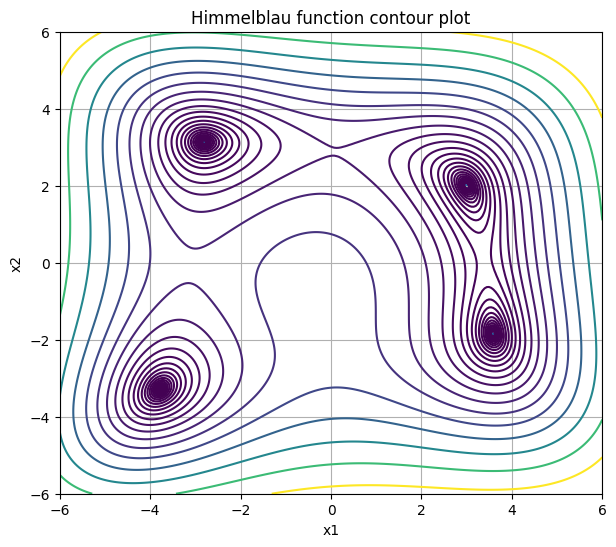

In [44]:
x1_grid = np.linspace(-6, 6, 250)
x2_grid = np.linspace(-6, 6, 250)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = (X1**2 + X2 - 11)**2 + (X1 + X2**2 - 7)**2

plt.figure(figsize=(7, 6))
levels = np.logspace(-1, 3, 25)
plt.contour(X1, X2, Z, levels=levels)
plt.scatter([3, -2.805118, -3.779310, 3.584428],
            [2, 3.131312, -3.283186, -1.848126],
            marker="x", s=80)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Himmelblau function contour plot")
plt.grid(True)
plt.show()

## 10.3 Minimize the quadratic function

We compare the analytical solution with SciPy.

In [45]:
quad = QuadraticFunction(n=5)
x0_quad = np.zeros(5)
result_quad = solve_with_scipy(quad, x0_quad, method="Newton-CG", tol=1e-12)

print("Analytical solution:", quad.analytical_minimizer())
print("SciPy solution:", result_quad.x)
print("Function value:", result_quad.fun)
print("Gradient norm:", np.linalg.norm(quad.gradient(result_quad.x)))
print("Success:", result_quad.success)

Analytical solution: [-2.5 -4.  -4.5 -4.  -2.5]
SciPy solution: [-2.5 -4.  -4.5 -4.  -2.5]
Function value: -8.75
Gradient norm: 0.0
Success: True


## 10.4 Compare `CG`, `Newton-CG`, and `BFGS` for \(f_3\) and \(f_4\)

The trivial optimum is

\[
x^*=0.
\]

We choose a nonzero starting value and vary the tolerance.

In [46]:
def compare_methods(problem, x0, tolerances=(1e-3, 1e-6, 1e-9, 1e-12)):
    methods = ["CG", "Newton-CG", "BFGS"]
    rows = []
    for tol in tolerances:
        for method in methods:
            result = solve_with_scipy(problem, x0, method=method, tol=tol)
            rows.append({
                "tol": tol,
                "method": method,
                "f(xmin)": result.fun,
                "||x||": np.linalg.norm(result.x),
                "||grad||": np.linalg.norm(problem.gradient(result.x)),
                "iterations": result.nit,
                "function evals": result.nfev,
                "success": result.success,
                "message": result.message,
            })
    return pd.DataFrame(rows)

n = 10
x0 = np.linspace(-2, 2, n)
print("initial x0 =", x0)
print("initial norm =", np.linalg.norm(x0))

initial x0 = [-2.       -1.555556 -1.111111 -0.666667 -0.222222  0.222222  0.666667
  1.111111  1.555556  2.      ]
initial norm = 4.036867138796656


### Results for \(f_3\)

In [47]:
f3 = RnSqrtFunction(n=n)
f3_results = compare_methods(f3, x0)
f3_results

,tol,method,f(xmin),||x||,||grad||,iterations,function evals,success,message
0,1.000000e-03,CG,1.0,1.001225e-03,6.332541e-04,13,25,True,Optimization terminated successfully.
1,1.000000e-03,Newton-CG,1.0,4.785055e-05,2.554611e-05,6,9,True,Optimization terminated successfully.
2,1.000000e-03,BFGS,1.0,6.174650e-04,3.647750e-04,12,15,True,Optimization terminated successfully.
3,1.000000e-06,CG,1.0,3.635889e-06,1.499492e-06,22,39,True,Optimization terminated successfully.
4,1.000000e-06,Newton-CG,1.0,3.973430e-14,2.121304e-14,8,10,True,Optimization terminated successfully.
5,1.000000e-06,BFGS,1.0,3.071501e-07,3.761685e-07,15,18,True,Optimization terminated successfully.
6,1.000000e-09,CG,1.0,9.044787e-09,8.363322e-09,32,54,False,Desired error not necessarily achieved due to ...
7,1.000000e-09,Newton-CG,1.0,3.973430e-14,2.121304e-14,8,10,True,Optimization terminated successfully.
8,1.000000e-09,BFGS,1.0,1.867833e-10,2.284502e-10,18,21,True,Optimization terminated successfully.
9,1.000000e-12,CG,1.0,9.044787e-09,8.363322e-09,32,54,False,Desired error not necessarily achieved due to ...


### Results for \(f_4\)

In [48]:
f4 = RnSqrtPlusQuadraticFunction(n=n)
f4_results = compare_methods(f4, x0)
f4_results

,tol,method,f(xmin),||x||,||grad||,iterations,function evals,success,message
0,1.000000e-03,CG,1.0,6.738693e-04,7.095239e-04,14,27,True,Optimization terminated successfully.
1,1.000000e-03,Newton-CG,1.0,1.826246e-06,1.615179e-06,7,8,True,Optimization terminated successfully.
2,1.000000e-03,BFGS,1.0,7.450870e-04,1.317675e-03,9,12,True,Optimization terminated successfully.
3,1.000000e-06,CG,1.0,4.088645e-07,6.919829e-07,23,43,True,Optimization terminated successfully.
4,1.000000e-06,Newton-CG,1.0,5.415981e-09,1.283160e-08,8,9,True,Optimization terminated successfully.
5,1.000000e-06,BFGS,1.0,7.793930e-07,2.078719e-06,12,15,True,Optimization terminated successfully.
6,1.000000e-09,CG,1.0,8.699620e-09,1.240679e-08,28,52,False,Desired error not necessarily achieved due to ...
7,1.000000e-09,Newton-CG,1.0,5.415981e-09,1.283160e-08,9,9,True,Optimization terminated successfully.
8,1.000000e-09,BFGS,1.0,9.742788e-10,6.836455e-09,15,18,False,Desired error not necessarily achieved due to ...
9,1.000000e-12,CG,1.0,8.699620e-09,1.240679e-08,28,52,False,Desired error not necessarily achieved due to ...


### Observation for \(f_3\) and \(f_4\)

Typical observations:

1. All methods move toward \(x=0\), the trivial minimizer.
2. `Newton-CG` usually needs fewer iterations because it uses the exact Hessian.
3. `CG` and `BFGS` can need more iterations because they do not use the exact Hessian directly.
4. For very strict tolerances such as \(10^{-12}\), `CG` or `BFGS` may report precision-loss warnings even when the solution is already very close to zero.
5. `Newton-CG` often remains successful here because the Hessian is available and implemented correctly.

Practical meaning: If exact gradient and Hessian are available, Newton-type methods can be very efficient. In large FEM problems, however, the Hessian may be expensive, so CG or quasi-Newton ideas can be more practical.

# 11. Extra Practice Problems with Solutions

These are useful for strengthening the topics used above.

## Problem 1: Random matrix with loops

Generate \(Z\in\mathbb{R}^{m\times m}\) with random values between \(-1\) and \(1\).

Important: each matrix entry is one scalar. Do not assign a whole matrix to one scalar entry.

In [49]:
m = 4
Z_loop = np.zeros((m, m))

for i in range(m):
    for j in range(m):
        Z_loop[i, j] = np.random.uniform(-1, 1)

print(Z_loop)

[[-0.020377 -0.896954 -0.672337 -0.881638]
 [-0.555882 -0.001842  0.334657 -0.589276]
 [-0.909808  0.512847 -0.367747 -0.13323 ]
 [ 0.134058 -0.728307 -0.479264 -0.562455]]


Vectorized solution:

In [50]:
Z_numpy = np.random.uniform(-1, 1, size=(m, m))
print(Z_numpy)

[[ 0.395708  0.171623  0.487058  0.732521]
 [ 0.812193 -0.849205 -0.609711  0.765228]
 [ 0.411028  0.789352 -0.183094 -0.296324]
 [ 0.934995 -0.449017 -0.597409  0.694433]]


## Problem 2: Spring energy class

For a spring with stiffness \(k\), the energy is

\[
E(u)=\frac{1}{2}ku^2.
\]

The derivative is

\[
\frac{dE}{du}=ku.
\]

In [51]:
class SpringEnergy:
    def __init__(self, k):
        self.k = k

    def value(self, u):
        return 0.5 * self.k * u**2

    def derivative(self, u):
        return self.k * u

spring = SpringEnergy(k=100)
u = 0.02
print("Energy =", spring.value(u))
print("Derivative =", spring.derivative(u))

Energy = 0.02
Derivative = 2.0


## Problem 3: Gradient descent for \(f(x)=x^2\)

For

\[
f(x)=x^2,
\]

we have

\[
f'(x)=2x.
\]

Gradient descent is

\[
x_{k+1}=x_k-\alpha f'(x_k).
\]

In [52]:
def f_simple(x):
    return x**2

def grad_f_simple(x):
    return 2*x

x = 5.0
alpha = 0.1
history = []

for k in range(20):
    history.append((k, x, f_simple(x)))
    x = x - alpha * grad_f_simple(x)

pd.DataFrame(history, columns=["iteration", "x", "f(x)"])

,iteration,x,f(x)
0,0,5.000000,25.000000
1,1,4.000000,16.000000
2,2,3.200000,10.240000
3,3,2.560000,6.553600
4,4,2.048000,4.194304
5,5,1.638400,2.684355
6,6,1.310720,1.717987
7,7,1.048576,1.099512
8,8,0.838861,0.703687
9,9,0.671089,0.450360


## Problem 4: Numerical derivative

Approximate

\[
f'(x)\approx\frac{f(x+h)-f(x-h)}{2h}.
\]

Test it for \(f(x)=x^3\). The exact derivative is \(3x^2\).

In [53]:
def numerical_derivative_1d(fun, x, h=1e-6):
    return (fun(x + h) - fun(x - h)) / (2*h)

def cubic(x):
    return x**3

x = 2.0
print("Numerical derivative:", numerical_derivative_1d(cubic, x))
print("Exact derivative:", 3*x**2)

Numerical derivative: 12.000000000789157
Exact derivative: 12.0


# 12. Final Summary

The notebook solved the PDF by implementing an abstract `Problem` class and four concrete function classes:

1. `Himmelblau`
2. `QuadraticFunction`
3. `RnSqrtFunction`
4. `RnSqrtPlusQuadraticFunction`

Each class implements:

- `value(x)`
- `gradient(x)`
- `hessian(x)`

Then `scipy.optimize.minimize` is used with:

- `CG`
- `Newton-CG`
- `BFGS`

Main conclusions:

- Himmelblau is non-convex, so different starting values can converge to different minima.
- The quadratic function has the analytical minimizer \(x^*=-Q^{-1}p\).
- For \(f_3\) and \(f_4\), the optimum is \(x=0\).
- `Newton-CG` is efficient when gradient and Hessian are implemented correctly.
- Very strict tolerances can cause precision-loss warnings even when the numerical result is already close to the optimum.